# Notebook Purpose
Here I'm just going to share the code for plots that I used for analyzing the information.
Het already had done some analysis, but I decided it would be reasonable to go in there myself and get an idea of what I should pick for the model and why.

So I read the book's chapter on data analysis in order to find seasonality / autocorrelations.

In [1]:
import pandas as pd
from statsforecast import StatsForecast
from statsforecast.models import AutoETS
import statsmodels.api as sm
# From FPP3 book (The Pythonic Way)
import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=".*FigureCanvasAgg is non-interactive.*"
)
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#569CC6", "#D55F03"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55F03", "#569CC6", "#13A076"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55F03", "#569CC6", "#13A076", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55F03", "#569CC6", "#13A076", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

E:\code\ua\s3\mis584\project_agg\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
import matplotlib.dates as matplotdates
import matplotlib.ticker as ticker
from functools import partial, reduce

import statsmodels.api as sm
from matplotlib.ticker import MaxNLocator
from prophet import Prophet
from statsforecast import StatsForecast
from statsforecast.adapters.prophet import AutoARIMAProphet
from statsforecast.models import MSTL, AutoETS, AutoARIMA, ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.api import VAR
from utilsforecast.evaluation import evaluate
from utilsforecast.feature_engineering import trend, fourier, pipeline
from utilsforecast.losses import rmse, mae, mape, mase, smape
from utilsforecast.preprocessing import fill_gaps

In [6]:
# This one is the original dataset, I think I just have some interpolation for the missing weather
# variables. Hence, not as good as the other ones.
pfp_2022 = pd.read_csv("./data/api_pfp_2022_train.csv")
pfp_2023 = pd.read_csv("./data/api_pfp_2023_dev.csv")

# I think these ones have Het's integration of weather variables
ptc_2023 = pd.read_csv("./data/het_ptc_2023_dev.csv")
ptc_2023["ds"] = pd.to_datetime(ptc_2023["ds"])
ptc_2022 = pd.read_csv("./data/het_ptc_train.csv")
ptc_2022["ds"] = pd.to_datetime(ptc_2022["ds"])

# This one has been treated to reduce outliers using 3*(Median Absolute Deviation) as a threshold
ptc_2022_ma = pd.read_csv("./data/ptc_2022_3mad.csv")
ptc_2022_ma["ds"] = pd.to_datetime(ptc_2022_ma["ds"])

# This one has been treated to reduce outliers with a more extreme treatment, using 2*MAD as threshold.
ptc_2022_mad2 = pd.read_csv("./data/ptc_2022_2mad.csv")
ptc_2022_mad2["ds"] = pd.to_datetime(ptc_2022_mad2["ds"])

# This one has all years in one dataset
ptc_weather = pd.read_csv("./data/ptc_weather.csv")
ptc_weather["ds"] = pd.to_datetime(ptc_weather["ds"])

## Plotting a Seasonal Plot of counts per day of the week.
I wanted to start by seeing if over time there was any obvious change.
While some are higher, some are lower, I would think that these years are pretty mixed,
so overall, there's not a clear pattern.

This plot below shows all the weeks in the year 2022.

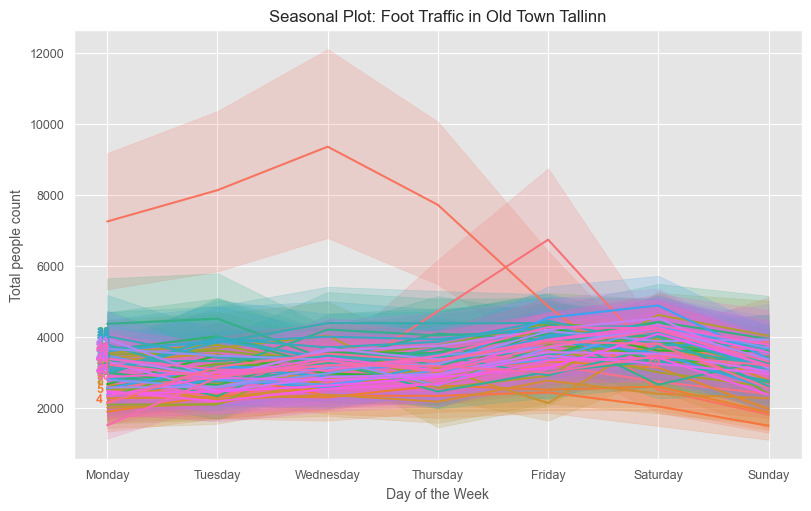

In [4]:
# Code adapted from Chapter 2, section 2.4 https://otexts.com/fpppy/nbs/02-graphics.html#time-plots
og_df = ptc_2022.copy()
og_df = og_df.assign(
    Month_name = og_df["ds"].dt.strftime("%b"),
    Year=og_df["ds"].dt.year,
    Month_num=og_df["ds"].dt.month,
    Week_num=og_df["ds"].dt.isocalendar().week,
    day_of_week_num = og_df["ds"].dt.isocalendar().day
)
unique_weeks = og_df["Week_num"].unique()
week_palette = sns.color_palette("husl", n_colors=len(unique_weeks))
fig, ax = plt.subplots()
sns.lineplot(
    data = og_df,
    x="day_of_week_num", y="y",
    hue="Week_num",
    palette=week_palette, legend=False,
    ax=ax
)
ax.set(
    title="Seasonal Plot: Foot Traffic in Old Town Tallinn",
    xlabel="Day of the Week",
    ylabel="Total people count",
    xticks=range(1, 8), #7 days in a week
    xticklabels=[ #Note that for dt.isocalendar().day Monday=1, Sunday=7
        "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
    ]
)
min_week = unique_weeks.min()
for week, subset in og_df.groupby("Week_num"):
    x = subset["day_of_week_num"].iloc[0] - 0.1
    y = subset["y"].median()
    color = week_palette[week - min_week]
    ax.text(x, y, str(week),
        ha="left", va="center", fontsize=9, weight="bold", color=color)
fig.show()

I think the spikes in there must be the outliers. I tried to use the reduced version using the 3*MAD control to see if that produced a more consistent plot.

The plot below also uses only 2022 data.

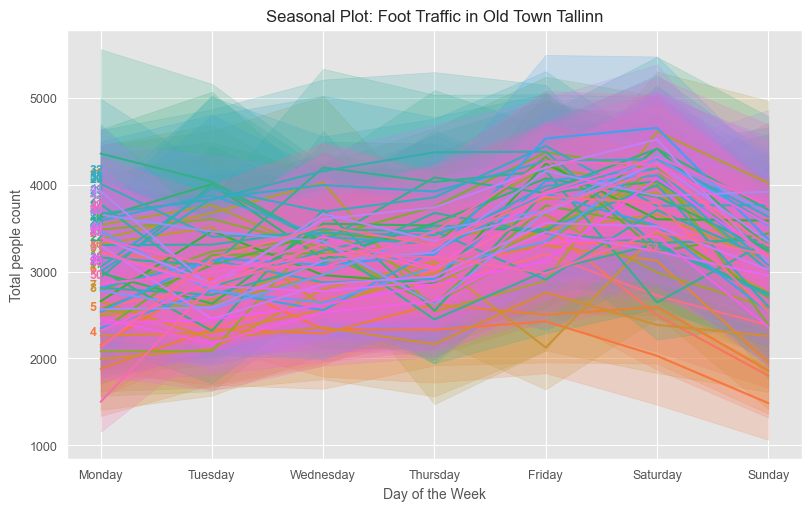

In [5]:
# Code adapted from Chapter 2, section 2.4 https://otexts.com/fpppy/nbs/02-graphics.html#time-plots
og_df = ptc_2022_ma.copy()
og_df = og_df.assign(
    Month_name = og_df["ds"].dt.strftime("%b"),
    Year=og_df["ds"].dt.year,
    Month_num=og_df["ds"].dt.month,
    Week_num=og_df["ds"].dt.isocalendar().week,
    day_of_week_num = og_df["ds"].dt.isocalendar().day
)
unique_weeks = og_df["Week_num"].unique()
week_palette = sns.color_palette("husl", n_colors=len(unique_weeks))
fig, ax = plt.subplots()
sns.lineplot(
    data = og_df,
    x="day_of_week_num", y="y",
    hue="Week_num",
    palette=week_palette, legend=False,
    ax=ax
)
ax.set(
    title="Seasonal Plot: Foot Traffic in Old Town Tallinn",
    xlabel="Day of the Week",
    ylabel="Total people count",
    xticks=range(1, 8), #7 days in a week
    xticklabels=[ #Note that for dt.isocalendar().day Monday=1, Sunday=7
        "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
    ]
)
min_week = unique_weeks.min()
for week, subset in og_df.groupby("Week_num"):
    x = subset["day_of_week_num"].iloc[0] - 0.1
    y = subset["y"].median()
    color = week_palette[week - min_week]
    ax.text(x, y, str(week),
        ha="left", va="bottom", fontsize=9, weight="bold", color=color)
fig.show()

## Plotting but with the entire dataset!
So I next thought to plot the entire dataset, but I will control for outliers with 3*MAD.
Note that this is using the entire dataset, so I can't just split this dataset later into train and test.
That would have some data leakage in it, since MAD is calculated with years from the test set too.

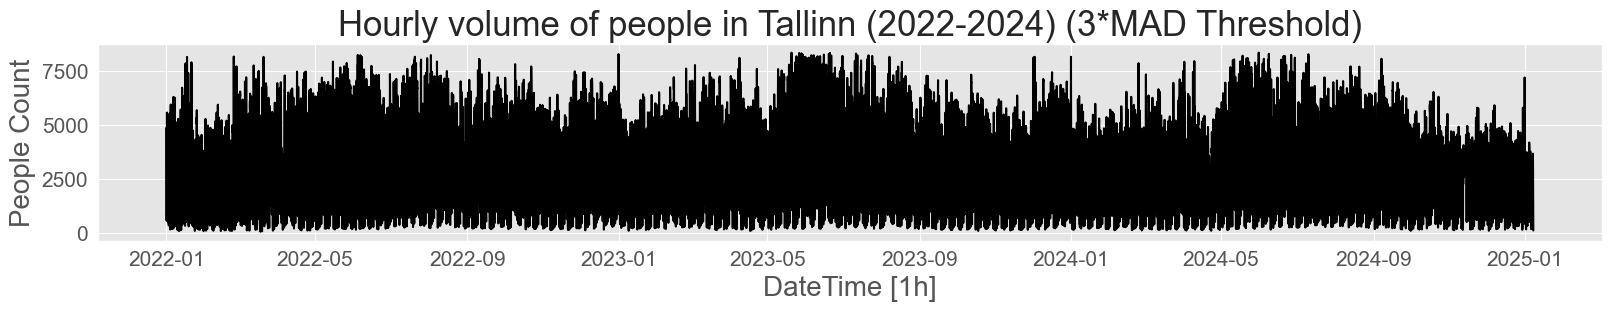

In [7]:
# Step 1: Calculate the Median for the time series
median = ptc_weather["y"].median()
# Step 2: Calculate the median absolute deviation
mad = (ptc_weather["y"] - median).abs().median()
# Step 3: The threshold is 3 times that
threshold = 3 * mad
# Then we simply find those values and set it to the median
ptc_weather_3mad = ptc_weather.copy()
ptc_weather_3mad.loc[(ptc_weather_3mad["y"] - median).abs() > threshold, "y"] = median
fig, ax = plt.subplots(figsize=(16,3)) #This is from the book.
plot_series(
    ptc_weather_3mad,
    xlabel="DateTime [1h]", ylabel="People Count",
    title="Hourly volume of people in Tallinn (2022-2024) (3*MAD Threshold)",
    ax = ax
)

We could be more strict on the threshold using 2*MAD. That might yield better models as well. Here's how that would look like when we modify the dataset.

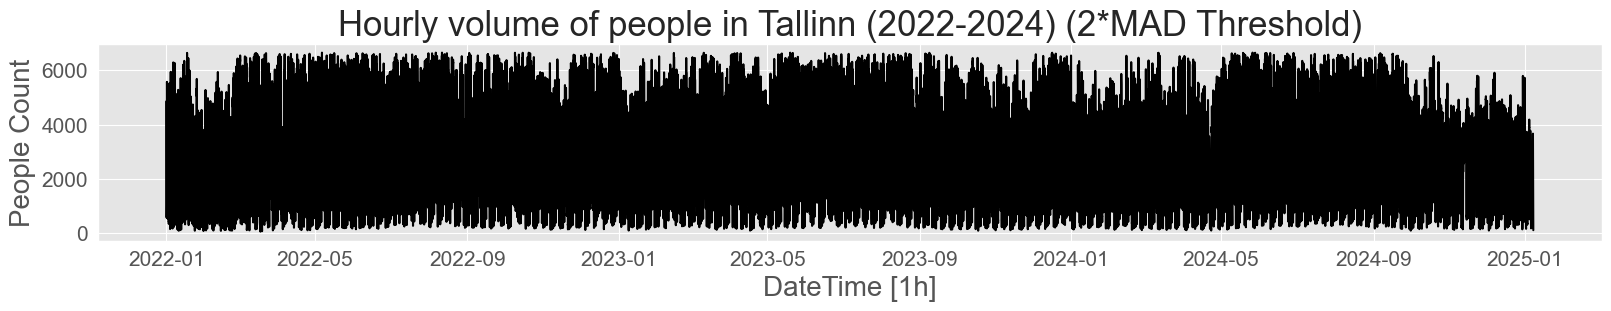

In [8]:
# Step 1: Calculate the Median for the time series
median = ptc_weather["y"].median()
# Step 2: Calculate the median absolute deviation
mad = (ptc_weather["y"] - median).abs().median()
# Step 3: The threshold is 3 times that
threshold = 2 * mad
# Then we simply find those values and set it to the median
ptc_weather_2mad = ptc_weather.copy()
ptc_weather_2mad.loc[(ptc_weather_2mad["y"] - median).abs() > threshold, "y"] = median
fig, ax = plt.subplots(figsize=(16,3)) #This is from the book.
plot_series(
    ptc_weather_2mad,
    xlabel="DateTime [1h]", ylabel="People Count",
    title="Hourly volume of people in Tallinn (2022-2024) (2*MAD Threshold)",
    ax = ax
)

### Plotting the yearly foot traffic counts.
I thought it would be interesting to see the movement in foot traffic as time goes on. Would we see an increase over time? Well, this chart shows that not really, in my opinion.

It's using 3*MAD data.

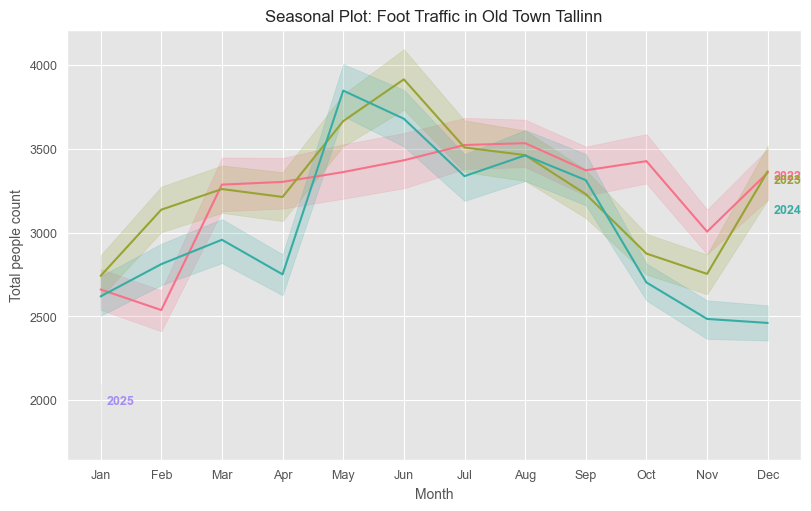

In [9]:
# Code adapted from Chapter 2, section 2.4 https://otexts.com/fpppy/nbs/02-graphics.html#time-plots
og_df = ptc_weather_3mad.copy()
og_df = og_df.assign(
    Month_name = og_df["ds"].dt.strftime("%b"),
    Year=og_df["ds"].dt.year,
    Month_num=og_df["ds"].dt.month,
    Week_num=og_df["ds"].dt.isocalendar().week,
    day_of_week_num = og_df["ds"].dt.isocalendar().day
)
unique_years = og_df["Year"].unique()
year_palette = sns.color_palette("husl", n_colors=len(unique_years))
fig, ax = plt.subplots()
sns.lineplot(
    data = og_df,
    x="Month_num", y="y",
    hue="Year",
    palette=year_palette, legend=False,
    ax=ax
)
ax.set(
    title="Seasonal Plot: Foot Traffic in Old Town Tallinn",
    xlabel="Month",
    ylabel="Total people count",
    xticks=range(1, 13), #7 days in a week
    xticklabels=[
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
    ]
)
min_year = unique_years.min()
for year, subset in og_df.groupby("Year"):
    x = subset["Month_num"].iloc[-1] + 0.1
    y = subset["y"].median()
    color = year_palette[year - min_year]
    ax.text(x, y, str(year),
        ha="left", va="bottom", fontsize=9, weight="bold", color=color)
fig.show()

I also plotted it by data with outliers reduced using a 2*MAD threshold

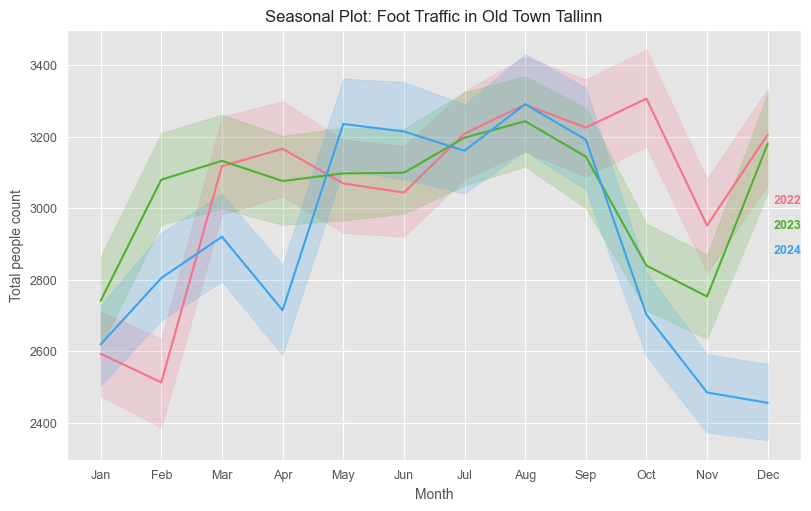

In [10]:
# Code adapted from Chapter 2, section 2.4 https://otexts.com/fpppy/nbs/02-graphics.html#time-plots
og_df = ptc_weather_2mad[ptc_weather_2mad["year"] < 2025].copy()
og_df = og_df.assign(
    Month_name = og_df["ds"].dt.strftime("%b"),
    Year=og_df["ds"].dt.year,
    Month_num=og_df["ds"].dt.month,
    Week_num=og_df["ds"].dt.isocalendar().week,
    day_of_week_num = og_df["ds"].dt.isocalendar().day
)
unique_years = og_df["Year"].unique()
year_palette = sns.color_palette("husl", n_colors=len(unique_years))
fig, ax = plt.subplots()
sns.lineplot(
    data = og_df,
    x="Month_num", y="y",
    hue="Year",
    palette=year_palette, legend=False,
    ax=ax
)
ax.set(
    title="Seasonal Plot: Foot Traffic in Old Town Tallinn",
    xlabel="Month",
    ylabel="Total people count",
    xticks=range(1, 13), #7 days in a week
    xticklabels=[
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
    ]
)
min_year = unique_years.min()
mean_val = og_df["y"].mean()
for year, subset in og_df.groupby("Year"):
    x = subset["Month_num"].iloc[-1] + 0.1
    y = mean_val + (70* (min_year-year) )
    color = year_palette[year - min_year]
    ax.text(x, y, str(year),
        ha="left", va="bottom", fontsize=9, weight="bold", color=color)
fig.show()

That sudden drop in 2024 is not normal, could it have something to do with reaching the end of the sensor program, at least with the API that they use? In any case, I don't think it's that suddenly nobody's going to Old Town Tallinn at all!

## A more formal plotting of seasonality
I now follow the book's suggested plots for looking out for seasonality. First, I just plot every day in all the years in the dataset.

That includes 2022, 2023, 2024, 2025 (the small bit of 2025 that exists).

We can see a very consistent pattern here!

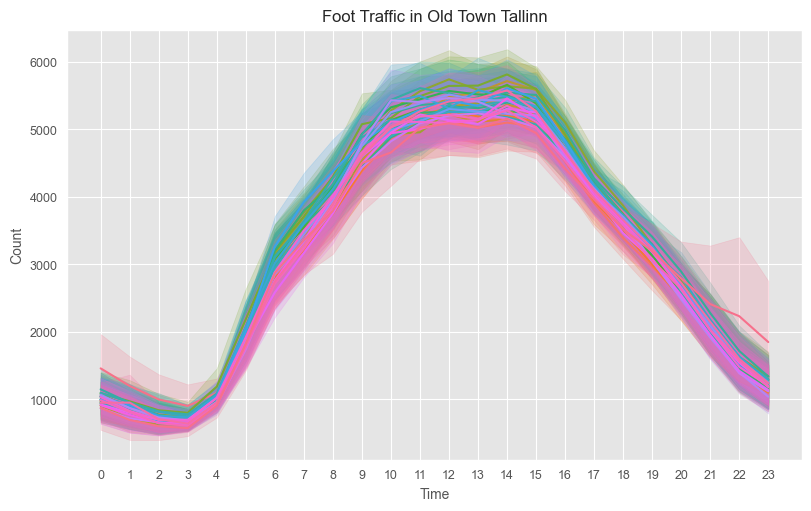

In [11]:
# Code adapted from Chapter 2, section 2.4: https://otexts.com/fpppy/nbs/02-graphics.html#time-plots
fig, ax = plt.subplots()
sns.lineplot(data=ptc_weather_3mad, x="hour", y="y",
    hue="day", palette="husl", legend=False, ax=ax)
ax.set(
    title="Foot Traffic in Old Town Tallinn",
    xlabel="Time",
    ylabel="Count",
)
unique_ticks = ptc_weather_3mad["hour"].unique()
ticks = range(0, len(unique_ticks), 1)
ticklabels = unique_ticks[::1]
ax.set_xticks(ticks, labels=ticklabels)
fig.show()

## Plotting all hours in a week, looking at the same pattern...
This is something the book also does, so I wanted to see what we could spy in our own data. Again, the pattern's pretty clear over all years.

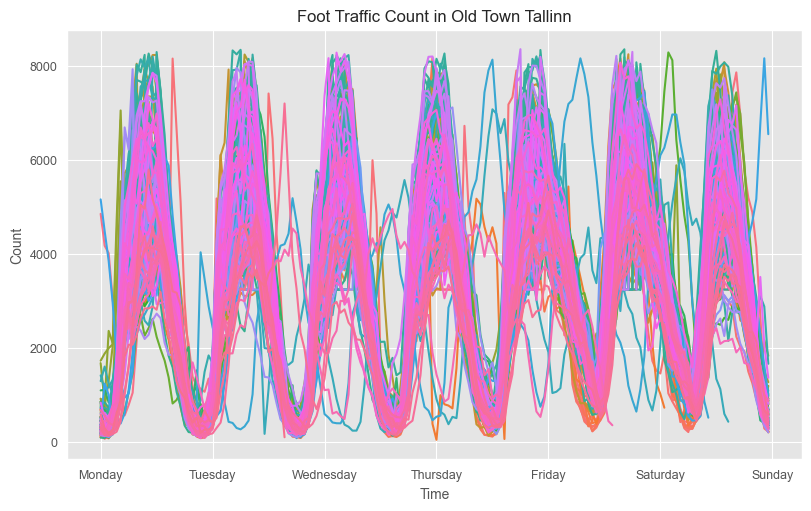

In [12]:
# Code adapted from Chapter 2, Section 2.4 https://otexts.com/fpppy/nbs/02-graphics.html#time-plots
ptc_weather_3mad = ptc_weather_3mad.assign(
    day_of_week_str=lambda x: x["ds"].dt.day_name(),
    week= lambda x: x["ds"].dt.to_period("W").dt.start_time
)
unique_weeks = ptc_weather_3mad["week"].unique()
palette = sns.color_palette("husl", n_colors=len(unique_weeks))
color_map = dict(zip(unique_weeks, palette))

fig, ax = plt.subplots()
for week, df_week in ptc_weather_3mad.groupby("week"):
    df_week.plot(x="day_of_week_str", y="y",
        ax=ax, color=color_map[week])
ax.get_legend().remove()
ax.set(
    title="Foot Traffic Count in Old Town Tallinn",
    xlabel="Time",
    ylabel="Count",
)
ax.set_xticks(np.linspace(0, 168, 7))
ax.set_xticklabels(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
fig.show()

## One more plot to round it out
The book uses a yearly plot, where we show all days in the year. I did not find this to be all that necessary or informative,
but for completion purposes I also apply it to our dataset.

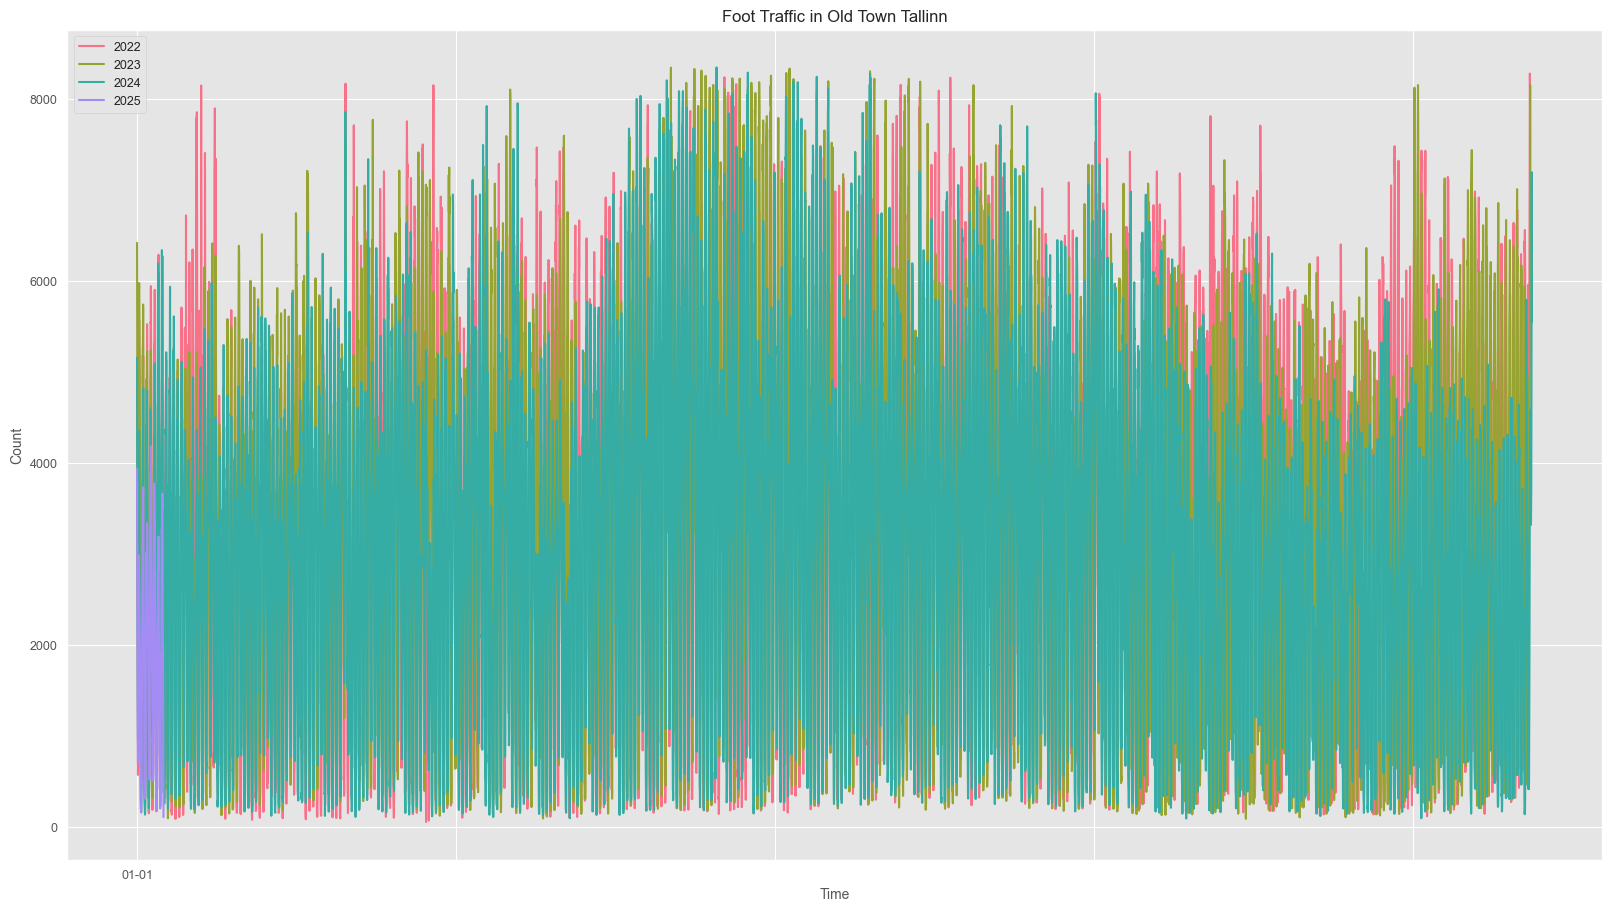

In [13]:
# Code adapted from Chapter 2, section 2.4
ptc_weather_3mad = ptc_weather_3mad.assign(
    day_of_year = lambda x: x["ds"].dt.strftime("%m-%d")
)
palette = sns.color_palette("husl", n_colors=ptc_weather_3mad["year"].nunique())
fig, ax = plt.subplots(figsize=(16, 9))
for i_year, (year, df_year) in enumerate(ptc_weather_3mad.groupby("year")):
    df_year.plot(x="day_of_year", y="y", ax=ax,
        label=str(year), color=palette[i_year])
ax.set(
    title="Foot Traffic in Old Town Tallinn",
    ylabel="Count",
    xlabel="Time",
)
fig.show()

# Autocorrelation plots
Now this is one way to find seasonality in our data. I started by showing lags up to a week past.

In [15]:
# This code comes from the book as well, Chapter 2, section 2.8
acf = sm.tsa.acf(ptc_weather_3mad["y"], nlags=24*7, fft=False, bartlett_confint=True)
acf_df = pd.Series(acf, name="ACF").to_frame().rename_axis("lag")

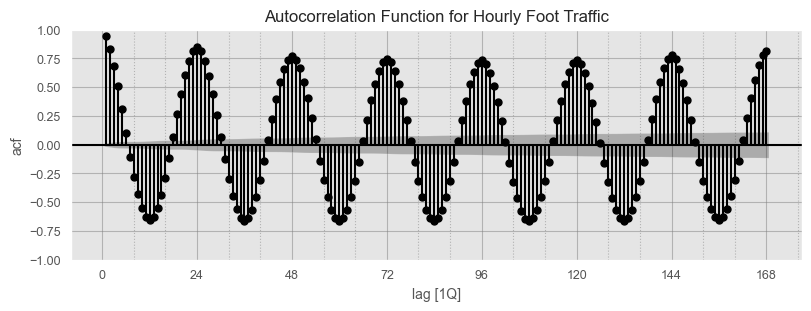

In [16]:
# From the book, Chapter 2, section 2.8
fig, ax = plt.subplots(figsize=(8, 3))
plot_acf(ptc_weather["y"], lags=24*7, ax=ax,
    zero=False, bartlett_confint=True, auto_ylims=False)
ax.set(
    title="Autocorrelation Function for Hourly Foot Traffic",
    xlabel="lag [1Q]", ylabel="acf",
)
# However, I expanded on it to add ticks that help us read the plot a little easier.
ax.xaxis.set_major_locator(ticker.MultipleLocator(24))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(8))
# This sets a grid on the major and minor locators I established.
ax.grid(which='major', color='gray', linestyle='-', alpha=0.5)
ax.grid(which='minor', color='gray', linestyle=':', alpha=0.5)
fig.show()

So this pattern's telling us that 24-hour (daily) seasonality is pretty strong!
Below I show a closer look.

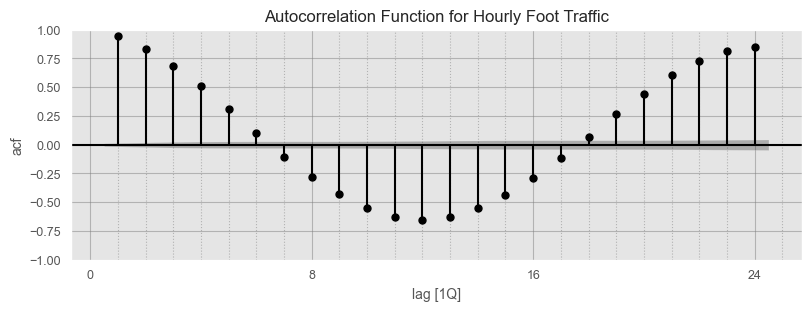

In [17]:
# Again, Chapter 2, section 2.8
fig, ax = plt.subplots(figsize=(8, 3))
plot_acf(ptc_weather["y"], lags=24, ax=ax,
    zero=False, bartlett_confint=True, auto_ylims=False)
ax.set(
    title="Autocorrelation Function for Hourly Foot Traffic",
    xlabel="lag [1Q]", ylabel="acf",
)
ax.xaxis.set_major_locator(ticker.MultipleLocator(8))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
# This sets a grid on the major and minor locators I established.
ax.grid(which='major', color='gray', linestyle='-', alpha=0.5)
ax.grid(which='minor', color='gray', linestyle=':', alpha=0.5)
fig.show()

## Looking at weekly seasonality via ACF
To look for weekly seasonality, we need to difference out the daily seasonality in this, and then we analyze the AC plot.

"Differencing" here means that you know there's a daily seasonality here. We need to remove that autocorrelation, and look at what's left, so see if we identify a significant autocorrelation left.

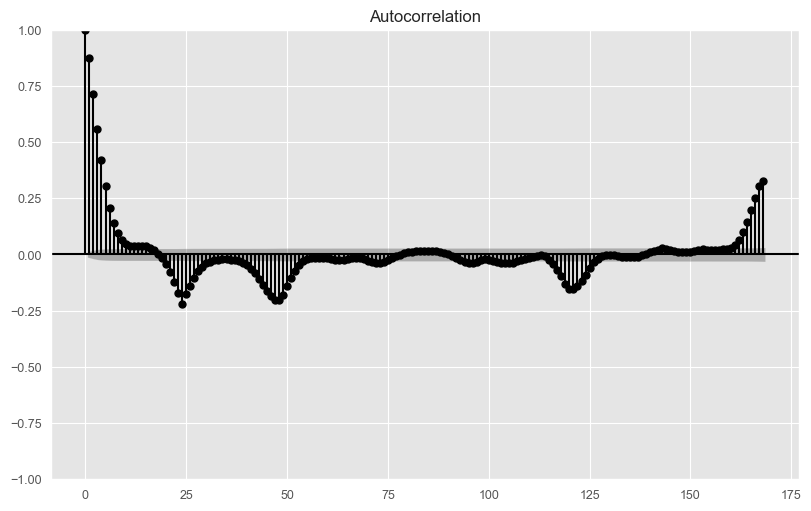

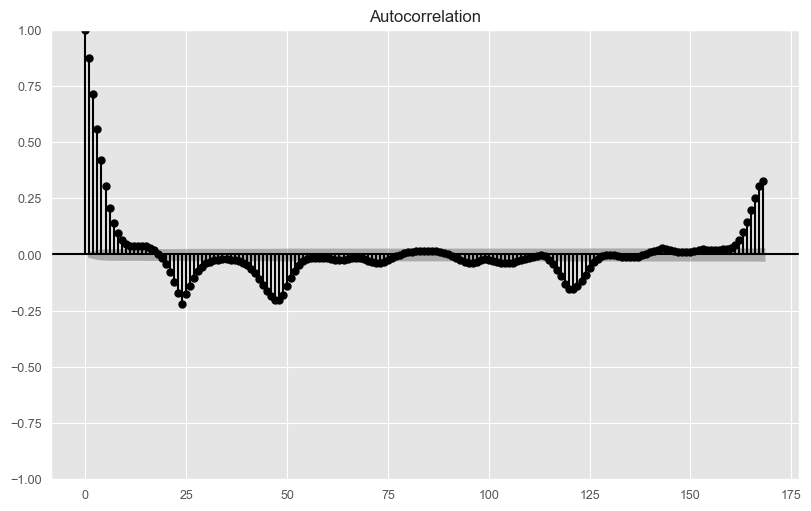

In [40]:
# Removing daily seasonality to inspect for weekly seasonality...
ptc_weather_weekly_analysis = ptc_weather["y"].diff(24).dropna()
plot_acf(ptc_weather_weekly_analysis, lags=24*7, bartlett_confint=True)

I think this does indicate a strong seasonality, as you can see that 168 hours earlier, the value spikes.
I don't know why it plots twice though.

## A New thought: Finding yearly, monthly seasonality
Okay, so I was elaborating on this and I thought, we don't need that much data to train, maybe 3-6 months is enough, which could reduce our data by half or more.

Yet the plot where we see how the counts go over the year seems to indicate that in the summer (July-August) the counts do increase. Any way to integrate this in the data?

Well, we can look for yearly seasonality first. But doing that with hourly lags seems infeasible! Imagine 24*365 lags!
What if instead I aggregate the data daily? That's still 365 lags?
But monthly, 12 lags only? Well maybe that's better, right?
Let's work on aggregating the data monthly, and then see if we can test for autocorrelations there.

And what do we do if we find an autocorrelation? We can integrate a Fourier Term and have the exogenous model work with that information.

Similarly, we can aggregate the data in a daily manner, then test for monthly autocorrelation.

In [41]:
# I'll use the 3MAD data
ptc_weather_3mad_monthly = ptc_weather_3mad.copy()
ptc_weather_3mad_monthly.head(3)

,year,month,day,hour,y,in_sum,out_sum,day_of_week,temp_mean,humidity_mean,...,wind_speed_mean,cloud_cover_mean,cloud_cover_low_mean,cloud_cover_mid_mean,cloud_cover_high_mean,ds,unique_id,day_of_week_str,week,day_of_year
0,2022,1,1,0,4852.0,2392.0,2460.0,5,-0.6,97.0,...,9.4,100.0,100.0,100.0,0.0,2022-01-01 00:00:00,all_sensors,Saturday,2021-12-27,01-01
1,2022,1,1,1,4175.0,1907.0,2268.0,5,-0.1,98.0,...,4.7,100.0,100.0,100.0,83.0,2022-01-01 01:00:00,all_sensors,Saturday,2021-12-27,01-01
2,2022,1,1,2,4016.0,1959.0,2057.0,5,-0.3,99.0,...,4.3,100.0,100.0,100.0,21.0,2022-01-01 02:00:00,all_sensors,Saturday,2021-12-27,01-01


In [42]:
# Get the hourly counts 
ptcm3mad_monthly_counts = ptc_weather_3mad_monthly.groupby(["year", "month"], as_index=False).agg({
    "y": ["sum"],
})
# From behzad.nouri (2014) https://stackoverflow.com/a/26325610
ptcm3mad_monthly_counts.columns = list(map("".join, ptcm3mad_monthly_counts.columns.values))

In [43]:
ptcm3mad_monthly_counts.rename(columns={
    "ysum": "y_sum"
}, inplace=True)

In [44]:
ptcm3mad_monthly_counts["day"] = 1

In [45]:
ptcm3mad_monthly_counts["ds"] = pd.to_datetime(ptcm3mad_monthly_counts[["year", "month", "day"]])

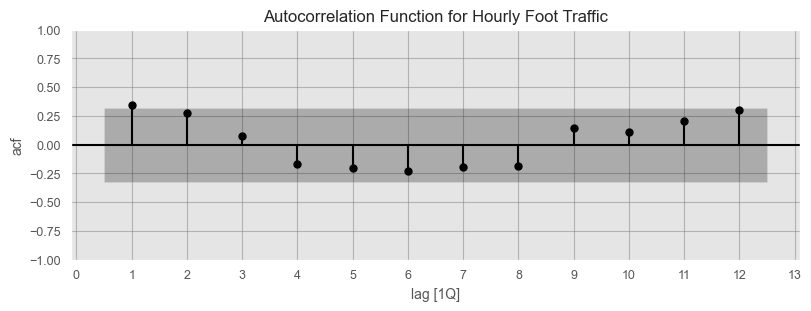

In [46]:
# This code comes from the book as well, Chapter 2, section 2.8
acf = sm.tsa.acf(ptcm3mad_monthly_counts["y_sum"], nlags=12, fft=False, bartlett_confint=True)
acf_df = pd.Series(acf, name="ACF").to_frame().rename_axis("lag")

# From the book, Chapter 2, section 2.8
fig, ax = plt.subplots(figsize=(8, 3))
plot_acf(ptcm3mad_monthly_counts["y_sum"], lags=12, ax=ax,
    zero=False, bartlett_confint=False, auto_ylims=False)
ax.set(
    title="Autocorrelation Function for Hourly Foot Traffic",
    xlabel="lag [1Q]", ylabel="acf",
)
# However, I expanded on it to add ticks that help us read the plot a little easier.
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.grid(which='major', color='gray', linestyle='-', alpha=0.5)
fig.show()

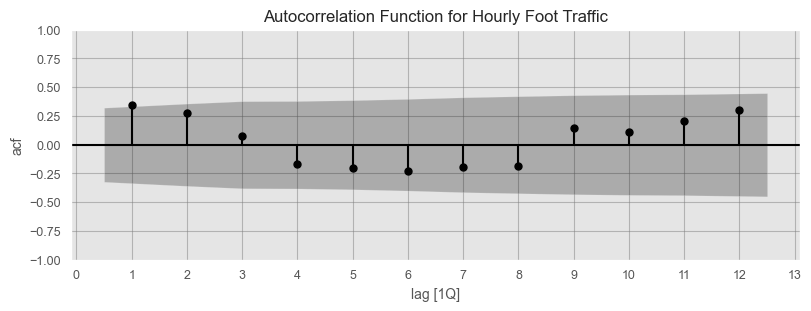

In [47]:
# This code comes from the book as well, Chapter 2, section 2.8
acf = sm.tsa.acf(ptcm3mad_monthly_counts["y_sum"], nlags=12, fft=False, bartlett_confint=True)
acf_df = pd.Series(acf, name="ACF").to_frame().rename_axis("lag")

# From the book, Chapter 2, section 2.8
fig, ax = plt.subplots(figsize=(8, 3))
plot_acf(ptcm3mad_monthly_counts["y_sum"], lags=12, ax=ax,
    zero=False, bartlett_confint=True, auto_ylims=False)
ax.set(
    title="Autocorrelation Function for Hourly Foot Traffic",
    xlabel="lag [1Q]", ylabel="acf",
)
# However, I expanded on it to add ticks that help us read the plot a little easier.
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.grid(which='major', color='gray', linestyle='-', alpha=0.5)
fig.show()

Okay, now on to try for monthly, of which I'm sincerely the least confident. I think these will show no significant autocorrelation.

In [48]:
# Get the hourly counts
ptc_weather_3mad_daily = ptc_weather_3mad.copy()
ptc3mad_daily_counts = ptc_weather_3mad_daily.groupby(["year", "month", "day"], as_index=False).agg({
    "y": ["sum"],
})
# From behzad.nouri (2014) https://stackoverflow.com/a/26325610
ptc3mad_daily_counts.columns = list(map("".join, ptc3mad_daily_counts.columns.values))
ptc3mad_daily_counts.rename(columns={
    "ysum": "y_sum"
}, inplace=True)
ptc3mad_daily_counts["ds"] = pd.to_datetime(ptc3mad_daily_counts[["year", "month", "day"]])

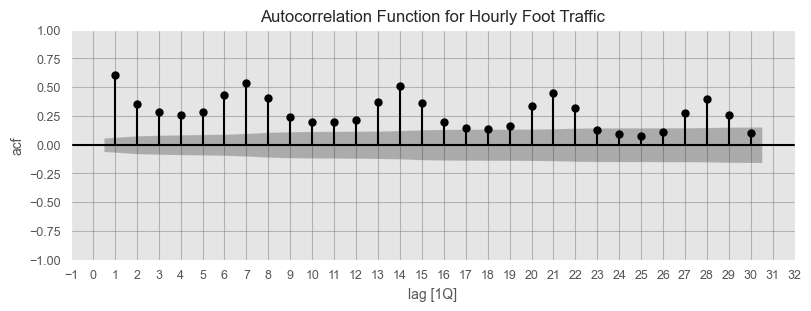

In [49]:
# This code comes from the book as well, Chapter 2, section 2.8
acf = sm.tsa.acf(ptc3mad_daily_counts["y_sum"], nlags=30, fft=False, bartlett_confint=True)
acf_df = pd.Series(acf, name="ACF").to_frame().rename_axis("lag")

# From the book, Chapter 2, section 2.8
fig, ax = plt.subplots(figsize=(8, 3))
plot_acf(ptc3mad_daily_counts["y_sum"], lags=30, ax=ax,
    zero=False, bartlett_confint=True, auto_ylims=False)
ax.set(
    title="Autocorrelation Function for Hourly Foot Traffic",
    xlabel="lag [1Q]", ylabel="acf",
)
# However, I expanded on it to add ticks that help us read the plot a little easier.
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.grid(which='major', color='gray', linestyle='-', alpha=0.5)
fig.show()

In [ ]:
That seems like the weekly seasonality doing it's magic. What if we difference it out?

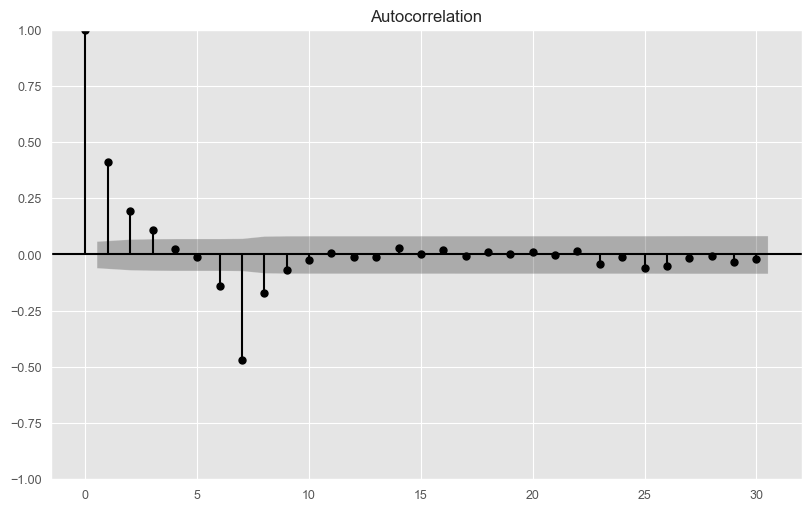

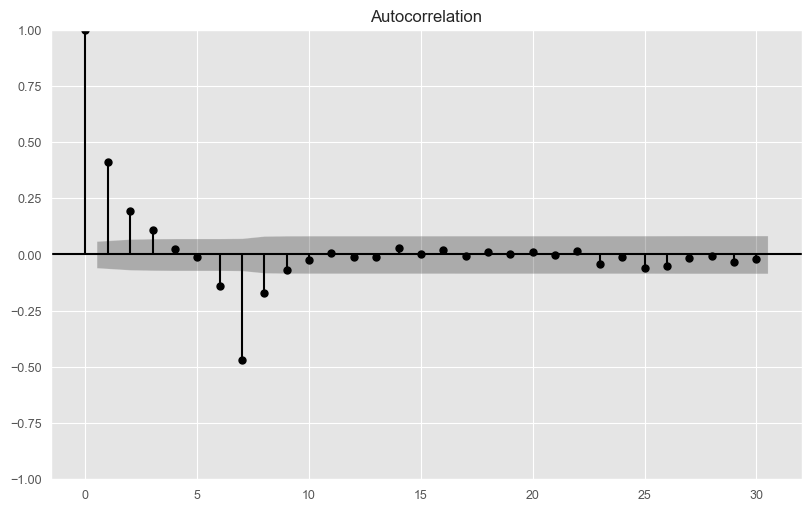

In [54]:
ptc_weather_monthly_analysis = ptc3mad_daily_counts["y_sum"].diff(7).dropna()
plot_acf(ptc_weather_monthly_analysis, lags=30, bartlett_confint=True)

So no monthly seasonality.

## A new thought part 2: Eliminate outliers in the remainder?
This is another thing I saw: the remainder had some spikes in there, we can treat them in the dataset, which has already been treated once, but doesn't seem right.

Instead, what if we treat the remainder values to delete these outliers, then retrain? Is that even possible?

## Fitting an MSTL model quickly to analyze it, using the seasonalities identified
As the title says, we'll do just that...

data
trend
seasonal24
seasonal168
remainder


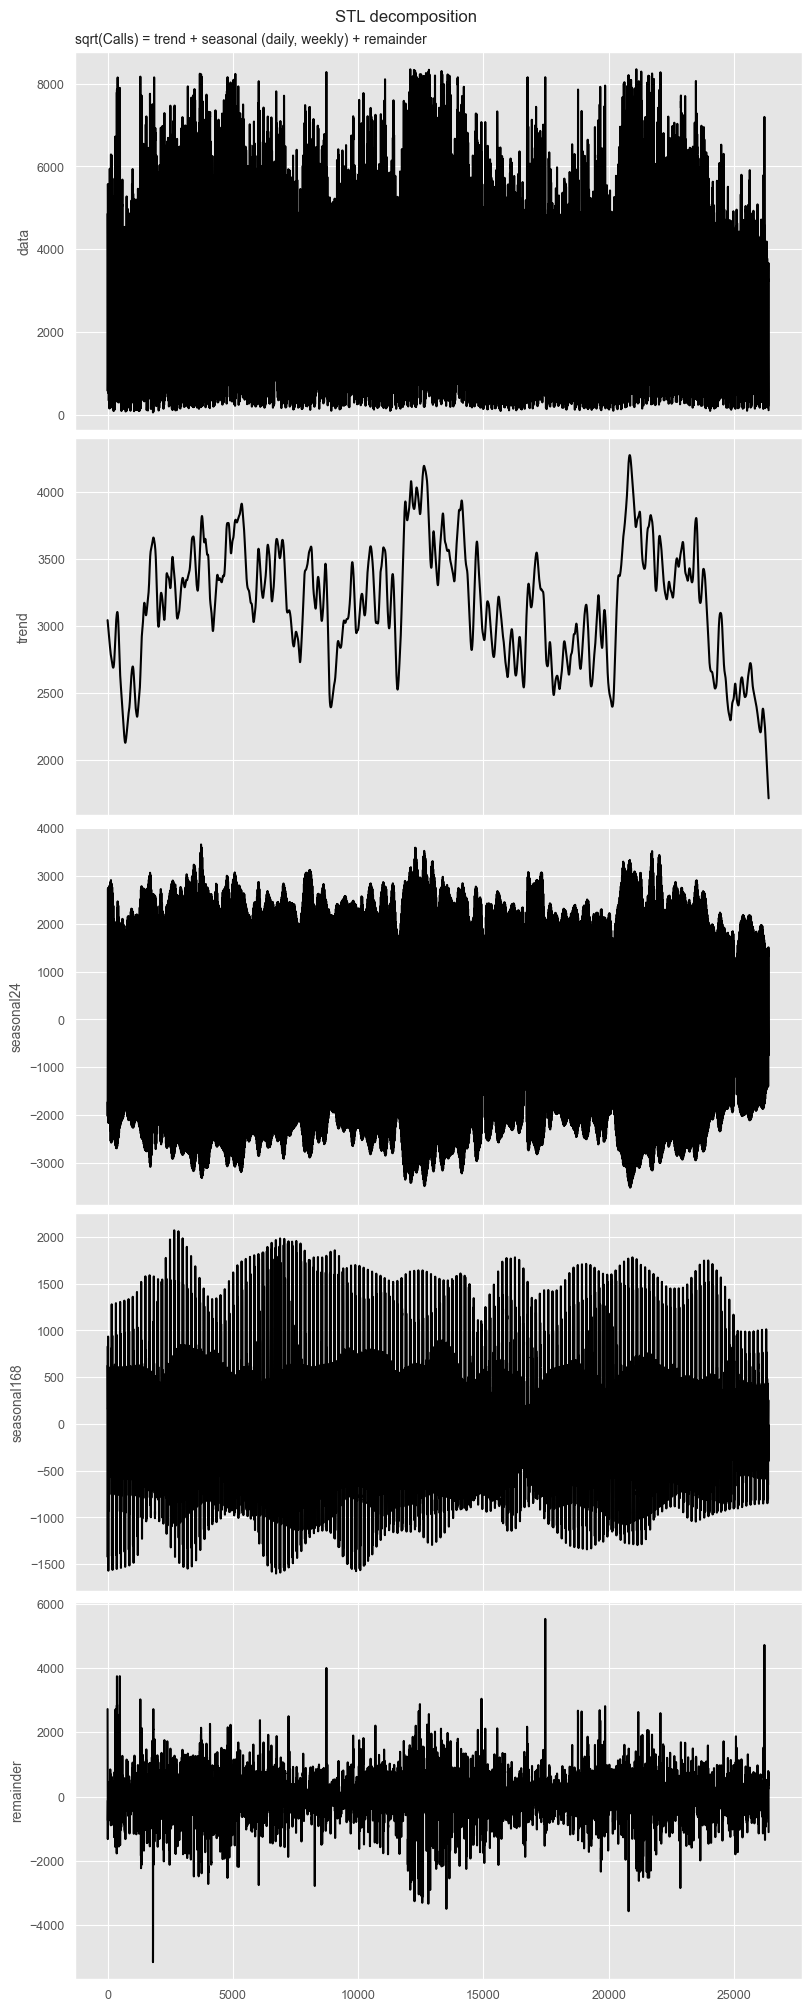

In [22]:
mstl1 = StatsForecast(
    models = [
        MSTL(
            season_length = [24, 24*7]
        )
    ],
    freq="1h"
)
# This also comes from the book
mstl1f = mstl1.fit(ptc_weather_3mad[["ds", "y", "unique_id"]])
dcmp_mstl1f = mstl1f.fitted_[0,0].model_ #The variable name stands for "decomposition MSTL multiseasoned fit", which is a pretty long name

fig, axes = plt.subplots(5, figsize=(8, 20), sharex=True)
for (ax, column) in zip(axes, dcmp_mstl1f.columns):
    print(column)
    sns.lineplot(data=dcmp_mstl1f, x=dcmp_mstl1f.index, y=column, ax=ax, color="k")
axes[0].set_title(
    "sqrt(Calls) = trend + seasonal (daily, weekly) + remainder",
    size="medium", loc="left")
axes[-1].set(xlabel="")
fig.suptitle("STL decomposition")
plt.show()

I would personally consider that the trend here doesn't look like it has any rhyme or reason; what I mean is I can't see a meaningful pattern in it.

In the remainder, those spikes seem to me like data outliers, BUT, there is this widening and then thinning of the amplitude which seems like something of interest we could try to work towards accounting for.

## Making the model
Okay, so this is the very first model I used with this information.

I use MSTL, with the daily, weekly seasonal components, and an AutoARIMA trend forecaster, which I think takes both remainder and trend. And I think AutoARIMA also takes in the Exogenous variables we use.

### Create a training dataset
Let's just work on 2022. We need to apply 3*MAD here on ONLY 2022 to avoid data leakage.

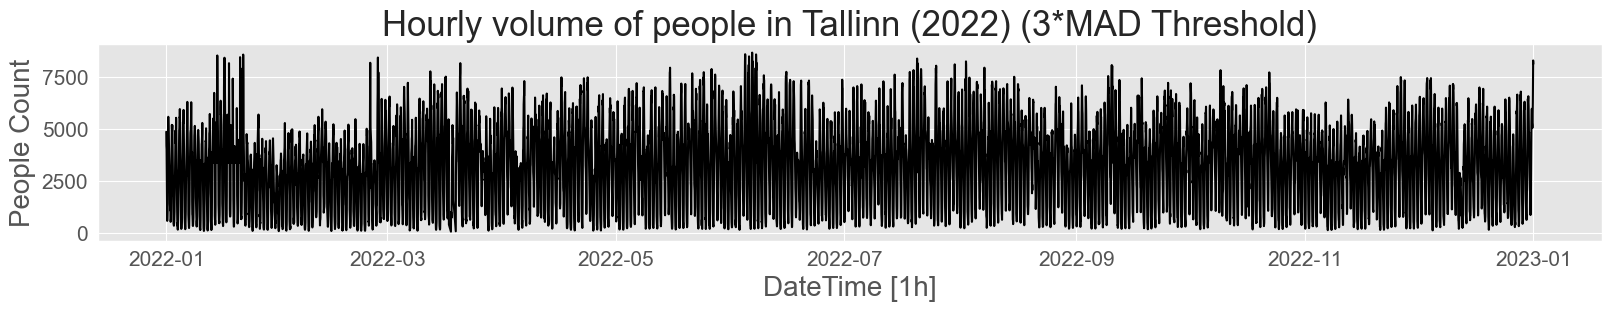

In [57]:
ptc_weather_3mad_nodataleakage_2022 = ptc_weather[ptc_weather["year"] < 2023].copy()
# Step 1: Calculate the Median for the time series
median = ptc_weather_3mad_nodataleakage_2022["y"].median()
# Step 2: Calculate the median absolute deviation
mad = (ptc_weather_3mad_nodataleakage_2022["y"] - median).abs().median()
# Step 3: The threshold is 3 times that
threshold = 3 * mad
# Then we simply find those values and set it to the median
ptc_weather_3mad_nodataleakage_2022 = ptc_weather_3mad_nodataleakage_2022.copy()
ptc_weather_3mad_nodataleakage_2022.loc[(ptc_weather_3mad_nodataleakage_2022["y"] - median).abs() > threshold, "y"] = median

# Let's keep only the data we need
ptc_weather_3mad_nodataleakage_2022 = ptc_weather_3mad_nodataleakage_2022.drop(
    columns=[
        "year", "month", "day", "hour",
        "in_sum", "out_sum" #, "day_of_week", #I'll opt for keeping in day_of_week, could be important as an exogenous variable
    ]
) 

fig, ax = plt.subplots(figsize=(16,3)) #This is from the book.
plot_series(
    ptc_weather_3mad_nodataleakage_2022,
    xlabel="DateTime [1h]", ylabel="People Count",
    title="Hourly volume of people in Tallinn (2022) (3*MAD Threshold)",
    ax = ax
)

## Making the Test dataset (2023)
We can take different parts of 2023, evaluate the model on just 8 hours at a time. Retraining is fast, so it makes sense we keep having the model integrate the past few hours!

In [60]:
ptc_weather_2023 = ptc_weather[ptc_weather["year"] == 2023].copy()
ptc_weather_2023_dev = ptc_weather_2023.copy()
ptc_weather_2023_dev = ptc_weather_2023_dev.drop(
    columns=[
        "year", "month", "day", "hour",
        "in_sum", "out_sum", "y" # "day_of_week",
    ]
)

### Training the model

In [61]:
from statsforecast.models import MSTL, AutoETS, AutoARIMA, ARIMA
mstl_dw_autoarima_exogenous = StatsForecast(
    models = [
        MSTL(
            season_length = [24, 24*7],
            trend_forecaster=AutoARIMA()
        )
    ],
    freq="1h" #The frequency of points in the dataset I guess? Or the frequency of generation of points?
)
# This also comes from the book
mstl_dw_autoarima_exogenous_3mad_nodataleakage_2022 = mstl_dw_autoarima_exogenous.fit(
    ptc_weather_3mad_nodataleakage_2022
)
dcmp_mstl_dw_ax_3mad_ndl_2022 = mstl_dw_autoarima_exogenous_3mad_nodataleakage_2022.fitted_[0,0].model_ #The variable name stands for "decomposition MSTL multiseasoned fit", which is a pretty long name
dcmp_mstl_dw_ax_3mad_ndl_2022.columns #You can see that it has the multiple seasons here as columns

Index(['data', 'trend', 'seasonal24', 'seasonal168', 'remainder'], dtype='object')

## Plotting our results (blue) agains the true data (red)

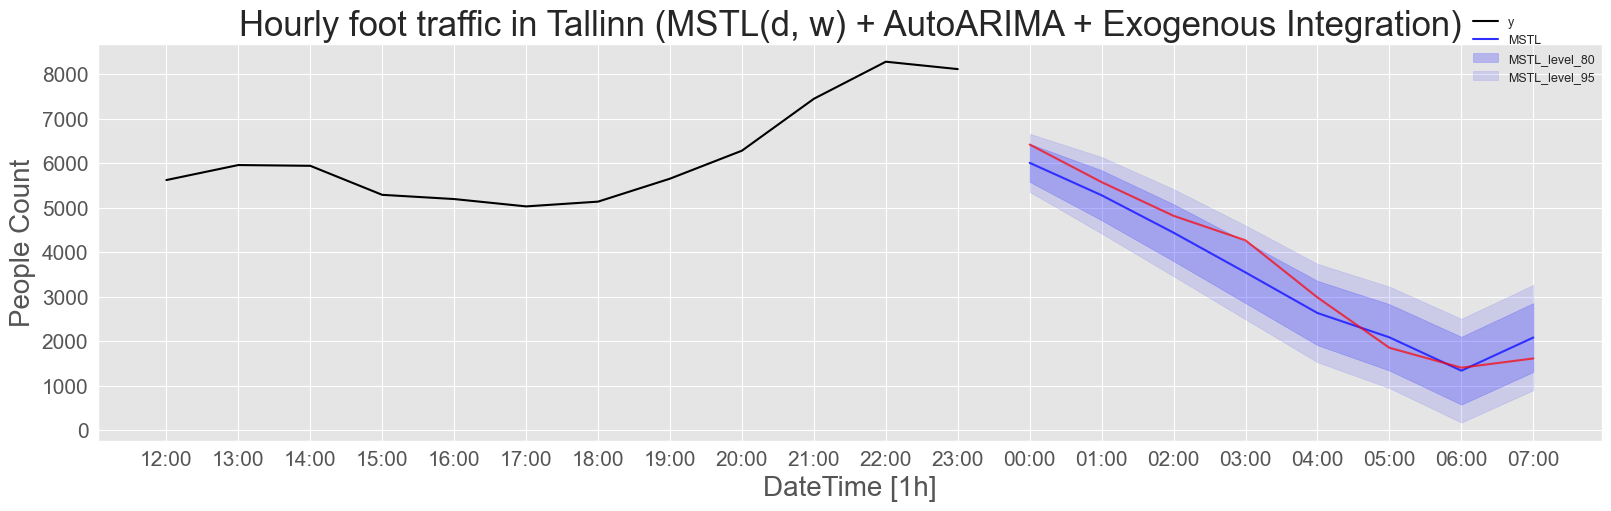

In [62]:
import matplotlib.dates as mdates

## Predicting
m_dw_ax_3m_ndl_2022_forecasts = mstl_dw_autoarima_exogenous_3mad_nodataleakage_2022.predict(
    h=8,
    level=[80, 95],
    X_df=ptc_weather_2023_dev.head(8) #Whatever data you provide, the number of data points must match the number of data points you want in the "horizon" argument ("h")
)
# Forecast, back-transform numerical results, and set ds with gaps
fig, ax = plt.subplots(figsize=(16, 5))
plot_series(
    df=ptc_weather_3mad_nodataleakage_2022, #I want the year 2022's data to be in black
    forecasts_df=m_dw_ax_3m_ndl_2022_forecasts, #The forecasts we want to show
    models=["MSTL"],
    level=[80, 95],     # again, seems like confidence interval stuff to me.
    max_insample_length=12, #How much to show from the black data (our training data). I'm showing the last month of the training data.
    xlabel="DateTime [1h]", ylabel="People Count",
    title="Hourly foot traffic in Tallinn (MSTL(d, w) + AutoARIMA + Exogenous Integration)",
    palette="black_and_blue", rm_legend=False, ax=ax)
ax.xaxis.set_major_locator(mdates.HourLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

com_data = ptc_weather_2023[(ptc_weather_2023["year"] == 2023)].head(8)

ax.plot(
    com_data["ds"],
    com_data["y"],
    color="red", alpha=0.7
)

fig

## Decomposition with this smaller model...

data
trend
seasonal24
seasonal168
remainder


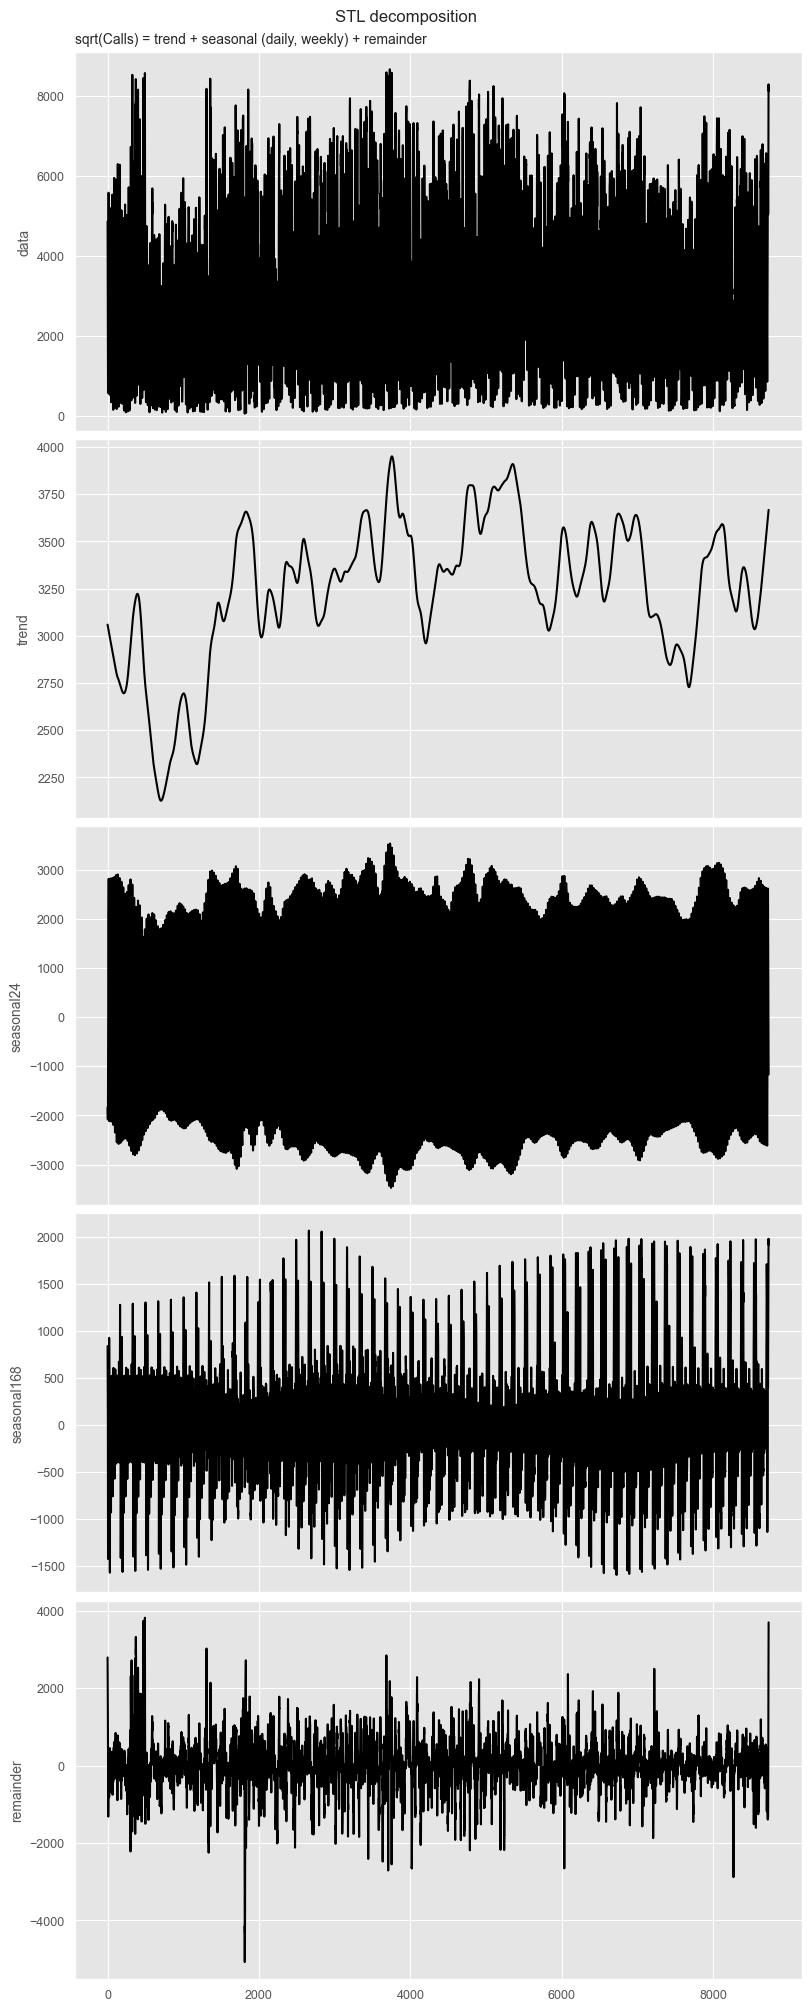

In [63]:
fig, axes = plt.subplots(5, figsize=(8, 20), sharex=True)
for (ax, column) in zip(axes, dcmp_mstl_dw_ax_3mad_ndl_2022.columns):
    print(column)
    sns.lineplot(data=dcmp_mstl_dw_ax_3mad_ndl_2022, x=dcmp_mstl_dw_ax_3mad_ndl_2022.index, y=column, ax=ax, color="k")
axes[0].set_title(
    "sqrt(Calls) = trend + seasonal (daily, weekly) + remainder",
    size="medium", loc="left")
axes[-1].set(xlabel="")
fig.suptitle("STL decomposition")
plt.show()

### Evaluation
Uses the book's code.

In [65]:
m_dw_ax_3m_ndl_2022_forecasts = mstl_dw_autoarima_exogenous_3mad_nodataleakage_2022.predict(
    h=8,
    level=[80, 95],
    X_df=ptc_weather_2023_dev.head(8) #Whatever data you provide, the number of data points must match the number of data points you want in the "horizon" argument ("h")
)
evaluation_df = m_dw_ax_3m_ndl_2022_forecasts.merge(
    ptc_weather_2023[["ds", "y"]],
    on=["ds"],
    how="inner"
)
evaluation = evaluate(
    evaluation_df,
    train_df=ptc_weather_3mad_nodataleakage_2022,
    metrics=[
        rmse, mae, mape,
        partial(mase, seasonality=24)
    ]
)

labels = {
    "method": "Method",
    "rmse": "RMSE", "mae": "MAE",
    "mape": "MAPE", "mase": "MASE",
}
evaluation_transformed = (
    evaluation
    .drop(columns=["unique_id"]).set_index("metric")
    .rename_axis("", axis="rows").rename_axis("Method", axis="columns")
    .transpose().reset_index().rename(columns=labels)
)
evaluation_transformed

,Method,RMSE,MAE,MAPE,MASE
0,MSTL,406.968,366.269,0.119,0.471


## Maybe less data works just fine...

In [66]:
from statsforecast.models import MSTL, AutoETS, AutoARIMA, ARIMA
mstl_dw_autoarima_exogenous = StatsForecast(
    models = [
        MSTL(
            season_length = [24, 24*7],
            trend_forecaster=AutoARIMA()
        )
    ],
    freq="1h"
)
# This also comes from the book
mstl_dw_autoarima_exogenous_3mad_nodataleakage_2022 = mstl_dw_autoarima_exogenous.fit(
    ptc_weather_3mad_nodataleakage_2022[
        ptc_weather_3mad_nodataleakage_2022["ds"] > "2022-07-31"
    ]
)
dcmp_mstl_dw_ax_3mad_ndl_2022 = mstl_dw_autoarima_exogenous_3mad_nodataleakage_2022.fitted_[0,0].model_ #The variable name stands for "decomposition MSTL multiseasoned fit", which is a pretty long name
dcmp_mstl_dw_ax_3mad_ndl_2022.columns #You can see that it has the multiple seasons here as columns

Index(['data', 'trend', 'seasonal24', 'seasonal168', 'remainder'], dtype='object')

data
trend
seasonal24
seasonal168
remainder


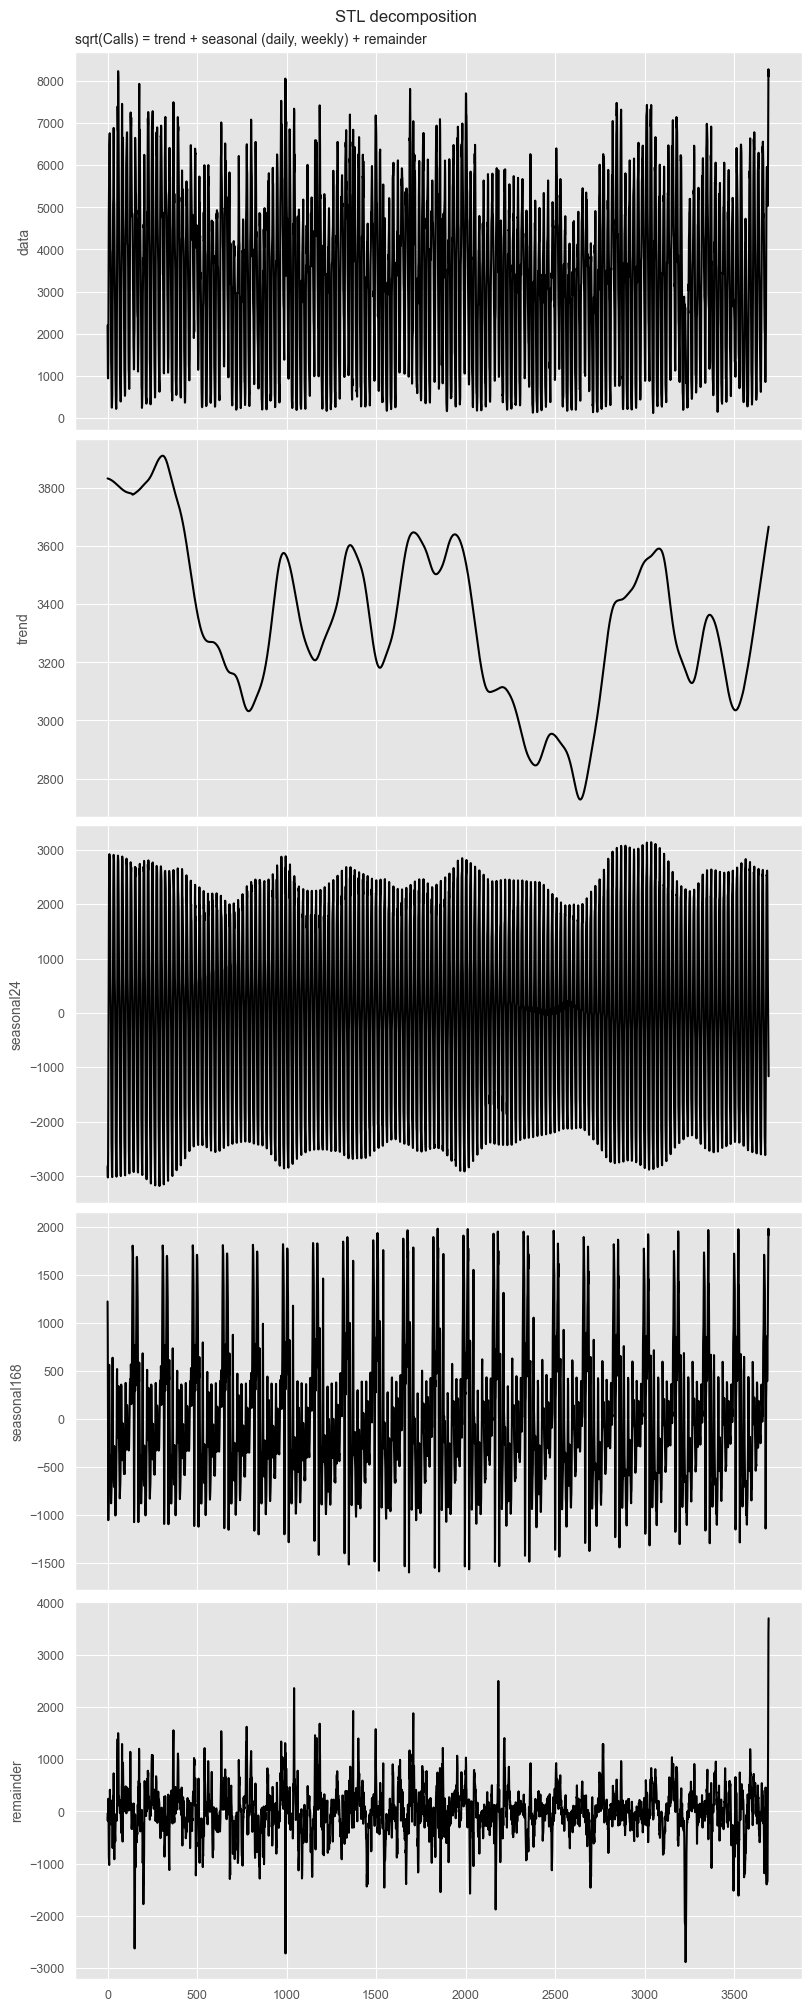

In [67]:
fig, axes = plt.subplots(5, figsize=(8, 20), sharex=True)
for (ax, column) in zip(axes, dcmp_mstl_dw_ax_3mad_ndl_2022.columns):
    print(column)
    sns.lineplot(data=dcmp_mstl_dw_ax_3mad_ndl_2022, x=dcmp_mstl_dw_ax_3mad_ndl_2022.index, y=column, ax=ax, color="k")
axes[0].set_title(
    "sqrt(Calls) = trend + seasonal (daily, weekly) + remainder",
    size="medium", loc="left")
axes[-1].set(xlabel="")
fig.suptitle("STL decomposition")
plt.show()

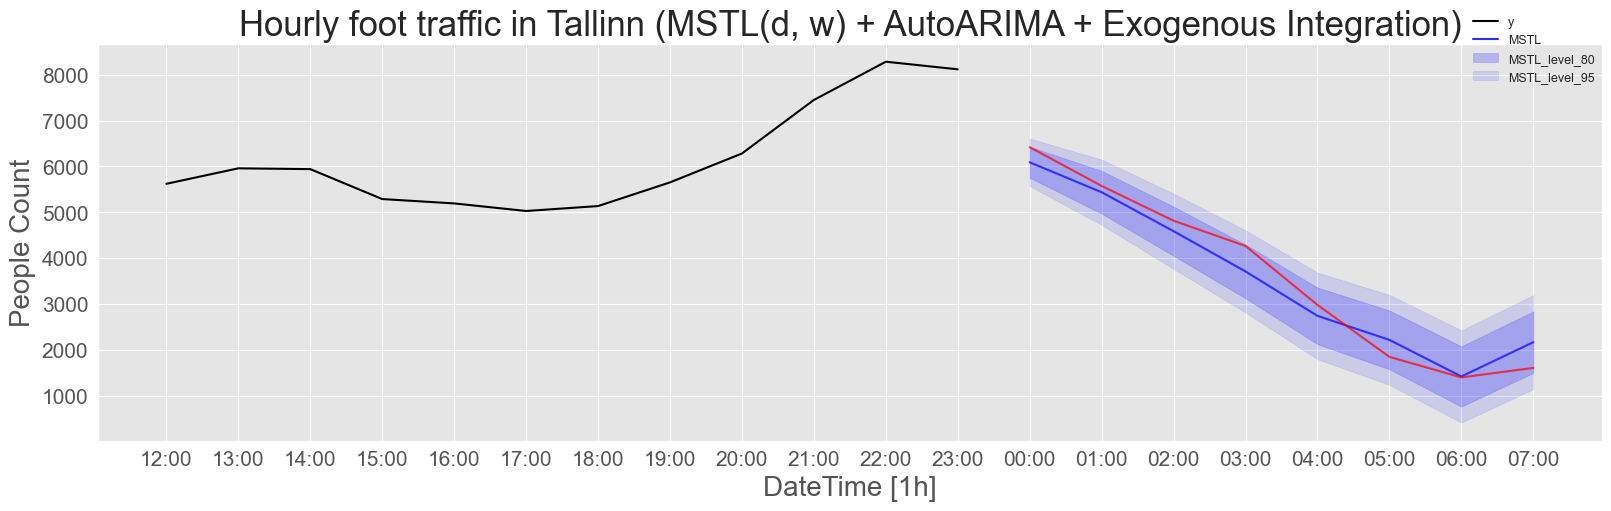

In [68]:
import matplotlib.dates as mdates

## Predicting
m_dw_ax_3m_ndl_2022_forecasts = mstl_dw_autoarima_exogenous_3mad_nodataleakage_2022.predict(
    h=8,
    level=[80, 95],
    X_df=ptc_weather_2023_dev.head(8) #Whatever data you provide, the number of data points must match the number of data points you want in the "horizon" argument ("h")
)
# Forecast, back-transform numerical results, and set ds with gaps
fig, ax = plt.subplots(figsize=(16, 5))
plot_series(
    df=ptc_weather_3mad_nodataleakage_2022, #I want the year 2022's data to be in black
    forecasts_df=m_dw_ax_3m_ndl_2022_forecasts, #The forecasts we want to show
    models=["MSTL"],
    level=[80, 95],     # again, seems like confidence interval stuff to me.
    max_insample_length=12, #How much to show from the black data (our training data). I'm showing the last month of the training data.
    xlabel="DateTime [1h]", ylabel="People Count",
    title="Hourly foot traffic in Tallinn (MSTL(d, w) + AutoARIMA + Exogenous Integration)",
    palette="black_and_blue", rm_legend=False, ax=ax)
ax.xaxis.set_major_locator(mdates.HourLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

com_data = ptc_weather_2023[(ptc_weather_2023["year"] == 2023)].head(8)

ax.plot(
    com_data["ds"],
    com_data["y"],
    color="red", alpha=0.7
)

fig

In [69]:
m_dw_ax_3m_ndl_2022_forecasts = mstl_dw_autoarima_exogenous_3mad_nodataleakage_2022.predict(
    h=8,
    level=[80, 95],
    X_df=ptc_weather_2023_dev.head(8) #Whatever data you provide, the number of data points must match the number of data points you want in the "horizon" argument ("h")
)
evaluation_df = m_dw_ax_3m_ndl_2022_forecasts.merge(
    ptc_weather_2023[["ds", "y"]],
    on=["ds"],
    how="inner"
)
evaluation = evaluate(
    evaluation_df,
    train_df=ptc_weather_3mad_nodataleakage_2022,
    metrics=[
        rmse, mae, mape,
        partial(mase, seasonality=24)
    ]
)

labels = {
    "method": "Method",
    "rmse": "RMSE", "mae": "MAE",
    "mape": "MAPE", "mase": "MASE",
}
evaluation_transformed = (
    evaluation
    .drop(columns=["unique_id"]).set_index("metric")
    .rename_axis("", axis="rows").rename_axis("Method", axis="columns")
    .transpose().reset_index().rename(columns=labels)
)
evaluation_transformed

,Method,RMSE,MAE,MAPE,MASE
0,MSTL,352.751,304.8,0.112,0.392


Compare the model using an entire year <br>
MSTL	406.968	366.269	0.119	0.471  <br>
vs the model using just five months in the past <br>
MSTL	352.751	304.8	0.112	0.392  <br>